# Imports

In [79]:
import pandas as pd
import os
from pathlib import Path
from tqdm import tqdm
import gc
from datetime import timedelta
from meteostat import Point
import meteostat as ms
Hourly = ms.hourly
import numpy as np
import math
import copy
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import pyarrow.parquet as pq

In [80]:
from joblib import dump, load
import keras
from sklearn import metrics
from sklearn.metrics import mean_squared_error, explained_variance_score, mean_absolute_error

# Primary Functions

In [81]:
# International Standard Atmosphere Model
def ISA_model(Alt, Tapt, Papt=None):
    """
    Alt: Altitude above airport [ft]
    Papt: Airport Pressure [hpa]
    Tapt: Airport Temperature [C]
    """
    P0 = 1013.2074890666767
    if Papt==None:

        theta = (273.15 + Tapt - 0.0065*0.3048*(Alt))/(273.15 + 15)
        delta = theta**5.256
        sigma = delta/theta

        return theta, delta, sigma
    else:
        theta = (273.15 + Tapt - 0.0065*0.3048*(Alt))/(273.15 + 15)
        theta_1 = (273.15 + Tapt - 0.0065*0.3048*(Alt))/(273.15 + Tapt)
        delta = (Papt*theta_1**5.256)/P0
        sigma = delta/theta
        
        return theta, delta, sigma
        

# --- Functions to Calculate Distance ---
def haversine(theta):
    return math.sin(theta/2)**2

def great_arc(lon1,lat1,lon2,lat2):
    lon1 *= math.pi/180
    lat1 *= math.pi/180
    lon2 *= math.pi/180
    lat2 *= math.pi/180
    return 2*math.asin(math.sqrt(haversine(lat2-lat1)+math.cos(lat1)*math.cos(lat2)*haversine(lon2-lon1)))

def earth_radius(lat):
    """
    Calculates the earth radius [km] at the given latitude [deg]
    """
    lat *= math.pi/180
    a = 6378.137*3280.84  # Radius at sea level at equator [feet]
    b = 6356.752*3280.84  # Radius at poles [feet]
    c = (a**2*math.cos(lat))**2
    d = (b**2*math.sin(lat))**2
    e = (a*math.cos(lat))**2
    f = (b*math.sin(lat))**2
    return math.sqrt((c+d)/(e+f))

def get_distance(lon1,lat1,lon2,lat2):
    """
    Calculates the distance [m] between two points on the great circle, ...
    ... using their respective longitude [deg] and latitude [deg]
    """
    R = (earth_radius(lat1) + earth_radius(lat2))/2
    return R*great_arc(lon1,lat1,lon2,lat2)

def get_lat_lon(lon_0_deg, lat_0_deg, x, y):
    A  =  6378137.000
    B  =  6356752.314
    lon_0 = lon_0_deg*np.pi/180
    lat_0 = lat_0_deg*np.pi/180
    
    Rp = A**2/np.sqrt(A**2*np.cos(lat_0)**2+B**2*np.sin(lat_0)**2)
    Rm = Rp**3*B**2/A**4
    
    E0 = 0.5*np.tan(lat_0)/Rp
    y0 = y - E0*x**2
    
    lat = lat_0_deg + y0/Rm*180/np.pi
    lon = lon_0_deg + x/(Rp*np.cos(lat_0)-y0*np.sin(lat_0))*180/np.pi
    
    return lat, lon

def get_x_y(lon_0_deg, lat_0_deg, lon_deg, lat_deg):
    A  =  6378137.000
    B  =  6356752.314
    
    lon_0 = lon_0_deg*np.pi/180
    lat_0 = lat_0_deg*np.pi/180
    lon = lon_deg*np.pi/180
    lat = lat_deg*np.pi/180
    
    Rp = A**2/np.sqrt(A**2*np.cos(lat_0)**2+B**2*np.sin(lat_0)**2)
    Rm = Rp**3*B**2/A**4
    y0 = Rm*(lat-lat_0)
    E0 = 0.5*np.tan(lat_0)/Rp
    
    x = (Rp*np.cos(lat_0) - y0*np.sin(lat_0))*(lon-lon_0)
    y = y0 + E0*x**2
    
    return x, y

# Function to calculate TAS and CAS
def get_velocities(df):
    """
    Calculates TAS and CAS using vectorized wind inputs.
    
    Parameters:
    - df: DataFrame containing flight data
    """
    
    # 1. Prepare Inputs (Ensure they are numpy arrays and radians)
    # Using .values ensures we are working with fast raw arrays, not pandas Series
    GS = df["groundspeed"].values.astype(float)
    sigma = df["sigma"].values.astype(float)
    
    # Convert degrees to radians
    Heading = np.radians(df["track"].values.astype(float))
    Climb_Angle = np.radians(df["Climb_Angle"].values.astype(float))
    wind_dir = np.radians(np.array(df["wind_direction"]).astype(float))
    wind_speed = np.array(df["wind_speed"]).astype(float)

    # 2. Create the Wind Vector Matrix (N x 3)
    # We calculate X and Y components for the whole column at once
    w_x = wind_speed * np.cos(wind_dir)
    w_y = wind_speed * np.sin(wind_dir)
    w_z = np.zeros_like(GS) # Vertical wind is assumed 0

    # Stack them into a matrix: [[x1, y1, z1], [x2, y2, z2], ...]
    Wind_vec = np.column_stack((w_x, w_y, w_z))

    # 3. Create the Ground Speed Vector Matrix (N x 3)
    # This replaces the slow list(zip(...)) logic
    gs_x = GS * np.cos(Climb_Angle) * np.cos(Heading)
    gs_y = GS * np.cos(Climb_Angle) * np.sin(Heading)
    gs_z = GS * np.sin(Climb_Angle)
    
    GS_vec = np.column_stack((gs_x, gs_y, gs_z))

    # 4. Calculate TAS
    # Standard Vector Triangle: True_Vel = Ground_Vel - Wind_Vel
    # axis=1 computes the norm for every row independently
    TAS = np.linalg.norm(GS_vec + Wind_vec, axis=1)

    # 5. Calculate CAS
    CAS = TAS * np.sqrt(sigma)

    return TAS, CAS

# Advanced Functions

In [82]:
def enhance_data(flight_data, flight_list, airports):
    # 1. Check if Latitude equals the PREVIOUS row's Latitude
    lat_same = flight_data['latitude'] == flight_data['latitude'].shift()
    
    # 2. Check if Longitude equals the PREVIOUS row's Longitude
    lon_same = flight_data['longitude'] == flight_data['longitude'].shift()
    
    # 3. Filter: Keep row if NOT (lat_same AND lon_same)
    #    This removes the row only if BOTH stayed the same
    flight_data = flight_data[~(lat_same & lon_same)]
    flight_data.reset_index(inplace=True, drop=True)
    if np.abs(flight_data.iloc[10]["altitude"]-flight_data.iloc[0]["altitude"])>100:
        return 0
    adep = flight_list.loc[flight_id]["adep"]
    adep_lat, adep_lon, adep_alt = airports.loc[adep, ["latitude_deg", "longitude_deg", "elevation_ft"]]
    if flight_data.iloc[1]["altitude"]-flight_data.iloc[0]["altitude"]==0:
        adep = flight_list.loc[flight_id]["adep"]
        adep_lat, adep_lon, adep_alt = airports.loc[adep, ["latitude_deg", "longitude_deg", "elevation_ft"]]
        P0 = 1013.25
        # Fetching data from meteostat
        time = flight_data['timestamp'].iloc[0].tz_localize(None)
        start = time - timedelta(minutes=30)
        end = time + timedelta(minutes=30)
        
        point = Point(adep_lat, adep_lon)
        data = Hourly(point, start, end).fetch()
        
        # Ajout de la vérification : on quitte et on ignore ce vol si data est vide
        if data is None or data.empty:
            return 0
            
        Pmsl_dep = data["pres"].mean()
        Tapt_dep = data["temp"].mean()
        
        Tb = Tapt_dep + adep_alt*0.0065*0.3048
        Papt_dep = Pmsl_dep*((273.15+Tapt_dep)/(273.15+Tb))**5.256
        flight_data["altitude"] = flight_data["altitude"] - flight_data.iloc[0]["altitude"]
    
    max_height_dep = 10000 #[ft]
    mask_1 = np.flatnonzero(flight_data["altitude"]>6000)
    if len(mask_1)==0:
        mask_1 = [len(flight_data)]
    mask_2 = np.flatnonzero(np.diff(flight_data.iloc[mask_1]["altitude"])<0)
    if len(mask_2)==0:
        mask_2 = [len(mask_1)-1]
    df_dep = flight_data.iloc[:mask_1[mask_2[0]]]
    mask_h = np.flatnonzero(df_dep["altitude"] >= max_height_dep)
    if len(mask_h)==0:
        mask_h = [len(df_dep)-1]
    df_dep = df_dep.iloc[:mask_h[0]+1]
    df_dep.reset_index(inplace=True, drop=True)
    df_dep["Time"] = df_dep["timestamp"] - df_dep["timestamp"].iloc[0]
    df_dep["Time"] = df_dep["Time"].dt.total_seconds()
    df_dep['wind_speed'] = np.sqrt(
        df_dep['u_component_of_wind']**2 + df_dep['v_component_of_wind']**2
    )
    df_dep['wind_direction'] = (
        270 - np.degrees(np.arctan2(df_dep['v_component_of_wind'], df_dep['u_component_of_wind']))
    ) % 360
    
    # Filling missing heading values    
    if df_dep["track"].isnull().values.any():
        x_temp, y_temp = get_x_y(adep_lon, adep_lat, df_dep["longitude"].values, df_dep["latitude"].values)
        x_diff = np.diff(x_temp)
        y_diff = np.diff(y_temp)
        computed_tracks = np.degrees(np.arctan2(x_diff, y_diff))
        computed_tracks = (computed_tracks + 360) % 360
        computed_tracks = np.r_[computed_tracks, computed_tracks[-1]]
        # 3. Apply only to rows where 'track' is currently NaN
        mask = df_dep['track'].isna()
        df_dep.loc[mask, 'track'] = computed_tracks[mask]
        if len(df_dep) > 1:
            df_dep.iloc[-1, df_dep.columns.get_loc("track")] = df_dep.iloc[-2]["track"]
    
    # Calculating Climb Angle, Roll Angle, Acceleration, and Distance, filling for missing values of ground speed
    counter = 0
    df_dep.loc[counter, "Distance"] = 0
    df_dep.loc[counter, "Acceleration"] = 0
    df_dep.loc[counter, "Roll_Angle"] = 0
    df_dep.loc[counter, "Climb_Angle"] = 0
    lat_prev = df_dep.iloc[0]["latitude"]
    lon_prev = df_dep.iloc[0]["longitude"]
    lat_temp = df_dep.iloc[1]["latitude"]
    lon_temp = df_dep.iloc[1]["longitude"]
    d_prev = get_distance(lon_temp,lat_temp,lon_prev,lat_prev)
    if math.isnan(df_dep.iloc[0]["groundspeed"]):
        d_tot = np.sqrt(d_prev**2 + (df_dep.iloc[1]["altitude"]-df_dep.iloc[0]["altitude"])**2)
        df_dep.loc[0, "groundspeed"] = 0.5924838012958963*d_tot/(df_dep.loc[1, "Time"] - df_dep.loc[0, "Time"])
    
    for i in range(len(df_dep)-1):
        counter += 1
        if counter == 1:
            x = d_prev*np.sin(np.pi*df_dep.iloc[counter-1]["track"]/180)
            y = d_prev*np.cos(np.pi*df_dep.iloc[counter-1]["track"]/180)
            d_vec_prev = [x,y,0]
            lat_prev = copy.copy(lat_temp)
            lon_prev = copy.copy(lon_temp)
            df_dep.loc[counter, "Distance"] = d_prev
            if math.isnan(df_dep.iloc[counter]["groundspeed"]):
                d_tot = np.sqrt(d_prev**2 + (df_dep.iloc[counter]["altitude"]-df_dep.iloc[counter-1]["altitude"])**2)
                df_dep.loc[counter, "groundspeed"] = 0.5924838012958963*d_tot/(df_dep.loc[counter, "Time"] - df_dep.loc[counter-1, "Time"])
            df_dep.loc[counter-1, "Acceleration"] = (df_dep.loc[counter, "groundspeed"] - df_dep.loc[counter-1, "groundspeed"])/(df_dep.loc[counter, "Time"] - df_dep.loc[counter-1, "Time"])
            df_dep.loc[counter, "Acceleration"] = df_dep.loc[counter-1, "Acceleration"]
            try:
                df_dep.loc[counter-1,"Climb_Angle"] = np.arctan((df_dep.loc[counter,"altitude"]-df_dep.loc[counter-1,"altitude"])/d_prev)*180/np.pi
                df_dep.loc[counter,"Climb_Angle"] = df_dep.loc[counter-1, "Climb_Angle"]
            except:
                df_dep.loc[counter, "Climb_Angle"] = 0
                df_dep.loc[counter-1,"Climb_Angle"] = 0
        else:
            lat_temp = df_dep.iloc[counter]["latitude"]
            lon_temp = df_dep.iloc[counter]["longitude"]
            d_temp = get_distance(lon_temp,lat_temp,lon_prev,lat_prev)
            x = d_prev*np.sin(np.pi*df_dep.iloc[counter-1]["track"]/180)
            y = d_prev*np.cos(np.pi*df_dep.iloc[counter-1]["track"]/180)
            d_vec_temp = [x,y,0]
            df_dep.loc[counter, "Distance"] = df_dep.loc[counter-1, "Distance"] + d_temp
            val = np.dot(d_vec_prev,d_vec_temp)/(np.linalg.norm(d_vec_temp)*np.linalg.norm(d_vec_prev))
            th = np.arccos(np.clip(val, -1.0, 1.0))
            y_d = np.tan(th/2)
            y_dd = 2*np.tan(th)/(d_temp + d_prev)
            k = y_dd/(1+y_d**2)**1.5
            df_dep.loc[counter-1, "Roll_Angle"] = np.sign(np.cross(d_vec_temp, d_vec_prev)[2])*180*np.arctan(2.85*k*df_dep.loc[counter-1, "groundspeed"]**2/9.81*0.3048)/np.pi
            if math.isnan(df_dep.loc[counter-1, "Roll_Angle"]):
                df_dep.loc[counter-1, "Roll_Angle"] = 0
            
            if math.isnan(df_dep.iloc[counter]["groundspeed"]):
                d_tot = np.sqrt(d_temp**2 + (df_dep.iloc[counter]["altitude"]-df_dep.iloc[counter-1]["altitude"])**2)
                df_dep.loc[counter, "groundspeed"] = 0.5924838012958963*d_tot/(df_dep.loc[counter, "Time"] - df_dep.loc[counter-1, "Time"])
            df_dep.loc[counter, "Acceleration"] = (df_dep.loc[counter, "groundspeed"] - df_dep.loc[counter-1, "groundspeed"])/(df_dep.loc[counter, "Time"] - df_dep.loc[counter-1, "Time"])
            df_dep.loc[counter-1, "Acceleration"] = (df_dep.loc[counter,"Acceleration"] + df_dep.loc[counter-1, "Acceleration"])/2
            try:
                df_dep.loc[counter,"Climb_Angle"] = np.arctan((df_dep.loc[counter,"altitude"]-df_dep.loc[counter-1,"altitude"])/d_temp)*180/np.pi
            except:
                df_dep.loc[counter, "Climb_Angle"] = 0
            df_dep.loc[counter-1, "Climb_Angle"] = (df_dep.loc[counter-1, "Climb_Angle"] + df_dep.loc[counter, "Climb_Angle"])/2
            lat_prev = copy.copy(lat_temp)
            lon_prev = copy.copy(lon_temp)
            d_prev = copy.copy(d_temp)
            d_vec_prev = copy.copy(d_vec_temp)
    df_dep.loc[0, "Roll_Angle"] = df_dep.loc[1, "Roll_Angle"]
    df_dep.loc[counter, "Roll_Angle"] = df_dep.loc[counter-1, "Roll_Angle"]
    # print(df_dep[df_dep["Climb_Angle"]<-2])
    if np.sum(df_dep["Climb_Angle"]<-2)>0:
        return 0
    # Calculating CAS and TAS
    theta, delta, sigma = ISA_model(Alt=df_dep["altitude"], Tapt=Tapt_dep, Papt=Papt_dep)
    df_dep["theta"] = theta*288.15/298.15
    df_dep["delta"] = delta
    df_dep["sigma"] = sigma
    TAS, CAS = get_velocities(df_dep)
    df_dep["TAS"] = TAS
    df_dep["CAS"] = CAS
    # For the Weight model
    df_dep["wind_dir_cos"] = np.cos((df_dep["wind_direction"] - df_dep["track"])*np.pi/180)
    df_dep["wind_dir_sin"] = np.sin((df_dep["wind_direction"] - df_dep["track"])*np.pi/180)

    return df_dep

# Data Cleaning

In [83]:
# 1. Setup Paths
base_dir = Path(os.getcwd())
raw_data_dir = base_dir / "Raw Data"
flight_list_path = base_dir / "flight_list.csv"
airports_file_path = base_dir / "airports.csv"
# Load the FULL flight list
flight_list = pd.read_csv(flight_list_path, index_col="flight_id")
# Get the available datasets
parquet_files = list(raw_data_dir.glob("*.parquet"))
# Get the airports file
airports = pd.read_csv(airports_file_path, encoding="ISO-8859-1")
airports = airports.dropna(subset=["icao_code"])
airports = airports.set_index("icao_code")

In [ ]:
output_file = "Data_Departures.csv"
desired_columns = ["flight_id", "timestamp", "Time", "Distance", "latitude", "longitude", 
                   "altitude", "groundspeed", "CAS", "TAS", "Acceleration", "track", 
                   "specific_humidity", "delta", "theta", "sigma", "Roll_Angle", 
                   "Climb_Angle", "wind_speed", "wind_direction", "wind_dir_cos", 
                   "wind_dir_sin", "aircraft_type"]

# 1. Clean up: Delete the old file if it exists so we start fresh
if os.path.exists(output_file):
    os.remove(output_file)
counter = 0
for file_path in tqdm(parquet_files, desc="Processing Days"):
    # Read the daily file
    df_adsb = pd.read_parquet(file_path)
    
    # 2. List Accumulation (The Key Fix)
    # Store processed flights in a simple list first. This is instant (zero memory copy).
    file_batch = []
    
    flights = df_adsb.groupby("flight_id")
    for flight_id, flight_data in flights:
        try:
            processed_flight = enhance_data(flight_data, flight_list, airports)
            if not isinstance(processed_flight, int):
                file_batch.append(processed_flight)
                counter += 1
                # if np.mod(counter,100)==0:
                #     print(counter)
        except:
            continue
    
    # 3. Concat ONCE per file
    # We only run the expensive concat operation once per day/file
    if file_batch:
        df_batch = pd.concat(file_batch)
        
        # Select only the columns you want
        # (Ensure your enhance_data function actually generates these or reindex will add NaNs)
        df_batch = df_batch.reindex(columns=desired_columns)
        
        # 4. Incremental Write
        # Append to CSV immediately and clear memory.
        # We write the header only if the file doesn't exist yet.
        file_exists = os.path.exists(output_file)
        df_batch.to_csv(output_file, mode='a', header=not file_exists, index=False)

print("Processing complete!")

Processing Days:   0%|          | 1/365 [00:01<10:49,  1.78s/it]

In [7]:
df = pd.read_csv("Data_Departures.csv")
df.to_parquet("Data_Departures.parquet", index=False)

# Weight Model Inputs Preparation

In [84]:
cols_to_avg = {
    "wind_speed": "wind_speed_1",
    "wind_dir_cos": "wind_dir_cos_1",
    "wind_dir_sin": "wind_dir_sin_1",
    "theta": "theta_1",
    "sigma": "sigma_1",
    "delta": "delta_1",
    "Roll_Angle": "roll_1"
}
all_names = ["Vg_1", "Vc_1", "wind_speed_1", "wind_dir_cos_1", "wind_dir_sin_1", "theta_1", "sigma_1", "delta_1", "roll_1", "climb_angle_1", "Total_Weight"]
x_names = all_names[:-1]
parquet_file = "Data_Departures.parquet"
batch_size = 100_000

In [85]:
def get_stable_cas_segment(df, std_threshold=2.0, min_points=5):
    """
    Finds the longest contiguous segment where CAS is stable (std dev < threshold).
    """
    # 1. Filter for airborne data only (skip ground roll noise)
    df_air = df[(df["altitude"] > 200) & (df["altitude"] < 2000)]
    
    if len(df_air) < min_points:
        return None

    # 2. Calculate rolling volatility (Standard Deviation over ~10-15 seconds)
    rolling_std = df_air['CAS'].rolling(window=15, center=True).std()
    
    # 3. Create a mask where volatility is low (CAS is constant)
    is_stable = rolling_std < std_threshold
    
    # 4. If no stable data found, return None
    if not is_stable.any():
        return None

    # 5. Group consecutive True values into segments
    # The (shift != current).cumsum() trick creates a unique ID for each contiguous block
    segment_ids = (is_stable != is_stable.shift()).cumsum()
    
    # 6. Find the largest stable block (longest duration)
    # We filter for 'is_stable' first to ignore the unstable blocks
    stable_blocks = df_air[is_stable].groupby(segment_ids)
    
    if len(stable_blocks) == 0:
        return None
        
    # Get the segment with the most data points
    best_segment = stable_blocks.apply(lambda x: x).loc[stable_blocks.size().idxmax()]

    # 7. Final length check
    if len(best_segment) < min_points:
        return None
        
    return best_segment

In [86]:
# Initialize the validation dataframe
df_validation = pd.DataFrame(columns=all_names)
# 1. Open the Parquet file using PyArrow directly
pf = pq.ParquetFile(parquet_file)
# Initialize buffer for the cut-off flight
leftover_df = pd.DataFrame()
# 2. Iterate through the file in batches
counter = 0
validation_rows = []
for batch in pf.iter_batches(batch_size=batch_size):
    # counter += 1
    # if counter>10:
    #     break
    # Convert the PyArrow batch to a Pandas DataFrame
    chunk = batch.to_pandas()
    
    # Glue the leftover from previous loop to the top
    chunk = pd.concat([leftover_df, chunk])
    
    # Identify the last flight_id in this combined chunk
    last_id = chunk['flight_id'].iloc[-1]
    
    if chunk['flight_id'].nunique() > 1:
        # Split: Process completed flights, keep the broken one
        current_batch = chunk[chunk['flight_id'] != last_id]
        leftover_df = chunk[chunk['flight_id'] == last_id]
    else:
        # Edge case: The whole chunk is just one massive flight
        leftover_df = chunk
        continue 

    # Process the complete flights
    for flight_id, flight_data in current_batch.groupby("flight_id"):
        tow = flight_list.loc[flight_id, "tow"]*2.20462
        if tow<120000:
            continue
        if (flight_data["altitude"] == 0).sum() < 1:
            continue
        segment = get_stable_cas_segment(flight_data)
        if segment is None:
            continue
        if len(segment) < 5:  # Arbitrary threshold: need at least 3 points to be valid
            continue
        if segment["Acceleration"].mean()>1:
            continue
        means = segment[list(cols_to_avg.keys())].mean()
        Distance = get_distance(segment.iloc[0]["longitude"],segment.iloc[0]["latitude"],segment.iloc[-1]["longitude"],segment.iloc[-1]["latitude"])
        d_alt = segment.iloc[-1]["altitude"]-segment.iloc[0]["altitude"]
        d_tot = np.sqrt(Distance**2+d_alt**2)
        # GS = d_tot/(segment.iloc[-1]["Time"]-segment.iloc[0]["Time"])*0.5924838012958963
        GS = segment["groundspeed"].mean()
        Climb_Angle = np.arctan(d_alt/Distance)*180/np.pi
        if (Climb_Angle>20) or (Climb_Angle<4):
            continue
        means = segment[list(cols_to_avg.keys())].mean()
        v_x = means["wind_speed"] * means["wind_dir_cos"] + GS * np.cos(Climb_Angle*np.pi/180)
        v_y = means["wind_speed"] * means["wind_dir_sin"]
        v_z = GS * np.sin(Climb_Angle * np.pi/180)
        TAS = np.sqrt(v_x**2 + v_y**2 + v_z**2)
        CAS = TAS * np.sqrt(means["sigma"])
        if (CAS>200) or (CAS<110):
            continue
        row_dict = means.rename(index=cols_to_avg).to_dict()
        row_dict["wind_speed_1"] = row_dict["wind_speed_1"] / 1.94384
        row_dict["flight_id"] = flight_id
        row_dict["Total_Weight"] = tow
        row_dict["Vg_1"] = GS
        row_dict["Vc_1"] = CAS
        row_dict["climb_angle_1"] = Climb_Angle
        validation_rows.append(row_dict)
        
# 3. Process the final remnant
if not leftover_df.empty:
    for flight_id, flight_data in leftover_df.groupby("flight_id"):
        tow = flight_list.loc[flight_id, "tow"]*2.20462
        if tow<120000:
            continue
        if (flight_data["altitude"] == 0).sum() < 1:
            continue
        segment = get_stable_cas_segment(flight_data)
        if segment is None:
            continue
        if len(segment) < 5:  # Arbitrary threshold: need at least 3 points to be valid
            continue
        if segment["Acceleration"].mean()>1:
            continue
        means = segment[list(cols_to_avg.keys())].mean()
        Distance = get_distance(segment.iloc[0]["longitude"],segment.iloc[0]["latitude"],segment.iloc[-1]["longitude"],segment.iloc[-1]["latitude"])
        d_alt = segment.iloc[-1]["altitude"]-segment.iloc[0]["altitude"]
        d_tot = np.sqrt(Distance**2+d_alt**2)
        # GS = d_tot/(segment.iloc[-1]["Time"]-segment.iloc[0]["Time"])*0.5924838012958963
        GS = segment["groundspeed"].mean()
        Climb_Angle = np.arctan(d_alt/Distance)*180/np.pi
        if (Climb_Angle>20) or (Climb_Angle<4):
            continue
        means = segment[list(cols_to_avg.keys())].mean()
        v_x = means["wind_speed"] * means["wind_dir_cos"] + GS * np.cos(Climb_Angle*np.pi/180)
        v_y = means["wind_speed"] * means["wind_dir_sin"]
        v_z = GS * np.sin(Climb_Angle * np.pi/180)
        TAS = np.sqrt(v_x**2 + v_y**2 + v_z**2)
        CAS = TAS * np.sqrt(means["sigma"])
        if (CAS>200) or (CAS<110):
            continue
        row_dict = means.rename(index=cols_to_avg).to_dict()
        row_dict["wind_speed_1"] = row_dict["wind_speed_1"] / 1.94384
        row_dict["flight_id"] = flight_id
        row_dict["Total_Weight"] = tow
        row_dict["Vg_1"] = GS
        row_dict["Vc_1"] = CAS
        row_dict["climb_angle_1"] = Climb_Angle
        validation_rows.append(row_dict)

df_validation = pd.DataFrame(validation_rows)

In [87]:
df_validation

,wind_speed_1,wind_dir_cos_1,wind_dir_sin_1,theta_1,sigma_1,delta_1,roll_1,flight_id,Total_Weight,Vg_1,Vc_1,climb_angle_1
0,0.716438,0.590674,-0.806893,0.947601,1.014823,0.995021,0.659198,248766540,129647.08834,157.333333,159.317342,9.129405
1,7.134420,0.995332,0.003453,0.943437,0.984558,0.961110,-8.340488,248768400,129746.29624,139.083333,151.455422,11.407230
2,5.491353,0.992969,-0.118257,0.944253,0.975460,0.953047,0.352842,248770266,158307.14834,163.400000,171.720343,9.511138
3,4.491710,0.300462,0.951720,0.941862,0.970280,0.945598,-0.563204,248773140,140690.02992,155.588235,156.015472,10.464897
4,3.237129,0.695363,-0.715263,0.931060,0.993305,0.956929,0.122929,248776822,149508.50992,174.384615,178.157935,9.573471
...,...,...,...,...,...,...,...,...,...,...,...,...
960,6.055304,0.973254,-0.226714,0.937434,0.976053,0.946745,-1.170039,257852930,151631.55898,150.727273,160.014635,12.166502
961,6.029466,0.991377,0.127781,0.924946,0.977992,0.936000,-0.127460,257915205,147363.41466,151.619048,161.249576,10.802314
962,7.177124,0.983312,0.180276,0.942430,0.952529,0.928855,0.297819,257951073,147303.88992,150.625000,160.217716,10.258478
963,2.478205,0.466063,-0.880188,0.921459,0.974425,0.929058,0.168920,257992376,127482.15150,160.888889,161.037305,12.466121


# Test Weight Model

In [88]:
model_weight = keras.models.load_model(r"Models\model_weight\model_weight.keras")
scaler_weight = load(r"Models\model_weight\scaler_weight.bin")

In [89]:
Data_test_scaled = pd.DataFrame(scaler_weight.transform(df_validation[all_names].values), index=df_validation.index, columns=all_names)

In [90]:
X_test_scaled = Data_test_scaled[x_names]
y_test_scaled = Data_test_scaled[["Total_Weight"]]

In [91]:
y_pred_scaled = model_weight.predict(X_test_scaled)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [92]:
output = scaler_weight.inverse_transform(np.concatenate((X_test_scaled, y_pred_scaled), axis=1))

In [93]:
print("r2 score for weight predictions: %.5f" % (metrics.r2_score(y_test_scaled, y_pred_scaled)))
print("MAE score for weight predictions: %.5f" % (metrics.mean_absolute_error(df_validation["Total_Weight"], output[:,-1])))
print("MAE score for weight predictions as percentage: %.5f %%" % np.mean(100*np.abs(df_validation["Total_Weight"]-output[:,-1])*df_validation["Total_Weight"]**-1))
print("Maximum error for weight predictions: %.5f" % np.max(np.abs(df_validation["Total_Weight"]-output[:,-1])))

r2 score for weight predictions: -0.36570
MAE score for weight predictions: 9483.46263
MAE score for weight predictions as percentage: 6.59999 %
Maximum error for weight predictions: 38141.01802


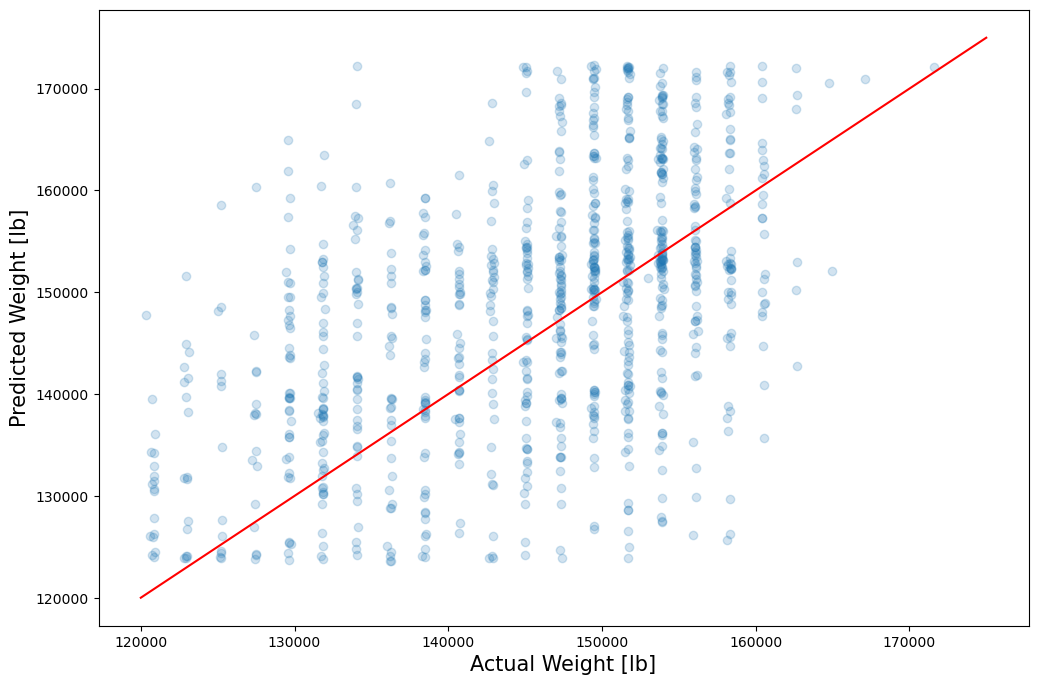

In [94]:
plt.figure(figsize=(12,8))
plt.scatter(df_validation[["Total_Weight"]], output[:,-1], alpha=0.2)
plt.ylabel("Predicted Weight [lb]", fontsize=15)
plt.xlabel("Actual Weight [lb]", fontsize=15)
plt.plot([120000, 175000], [120000, 175000], "r")
# plt.xlim([430000*0.453592, 690000*0.453592])
# plt.ylim([0, 210000])
# plt.xticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.yticks(ticks=[240000, 260000, 280000, 300000, 320000, 340000, 360000, 380000, 400000], labels=["240,000", "260,000", "280,000", "300,000", "320,000", "340,000", "360,000", "380,000", "400,000"])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_0.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_scatter.png", dpi=300)
plt.show()

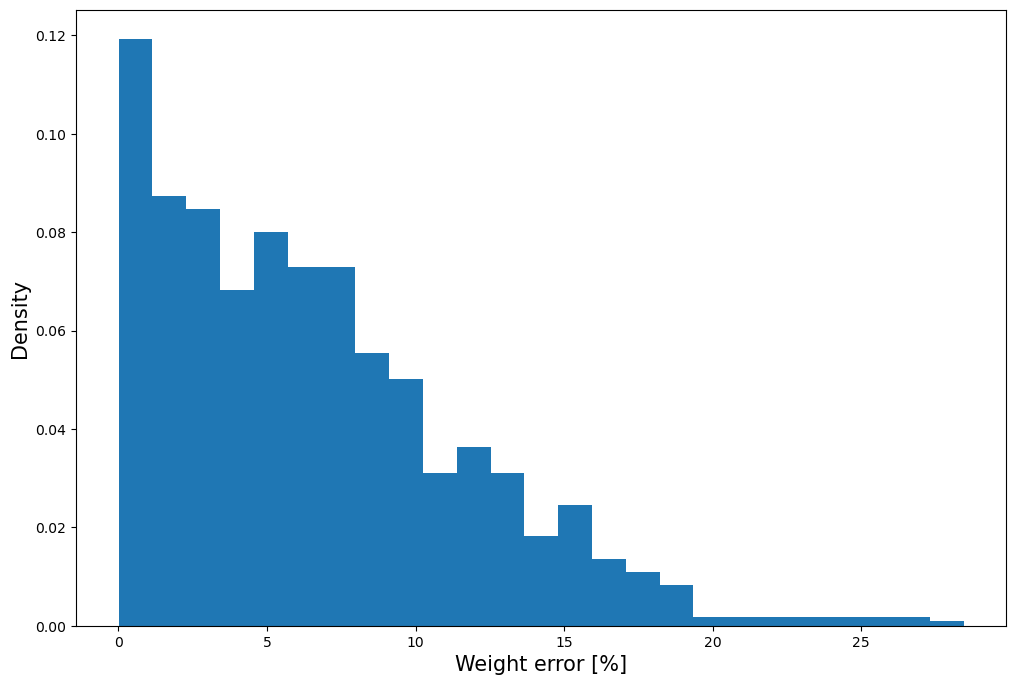

In [95]:
errors_lst = np.abs(100*(output[:,-1] - df_validation["Total_Weight"].values)/df_validation["Total_Weight"])
plt.figure(figsize=(12,8))
plt.hist(errors_lst, bins=25, ec="k", density=True)
plt.xlabel("Weight error [%]", fontsize=15)
plt.ylabel("Density", fontsize=15)
# plt.xlim([-5,5])
# plt.savefig("E:\Stuff From Laptop\Polimi\Thesis\Stage 9 - Final Models\Figures\Weight_1.png", bbox_inches="tight", facecolor='white', transparent=False)

# Save the figure (high resolution)
plt.savefig("weight_predictions_error_distribution.png", dpi=300)
plt.show()

In [96]:
df_validation["Estimated_Weight"] = output[:,-1]
df_validation["Error"] = 100*(df_validation["Estimated_Weight"] - df_validation["Total_Weight"])/df_validation["Total_Weight"]
df_validation.to_csv("results.csv")

In [97]:
df_validation[np.abs(df_validation["Error"])>20]

,wind_speed_1,wind_dir_cos_1,wind_dir_sin_1,theta_1,sigma_1,delta_1,roll_1,flight_id,Total_Weight,Vg_1,Vc_1,climb_angle_1,Estimated_Weight,Error
27,1.297485,0.415411,0.900654,0.946205,0.964576,0.944380,-8.228724,248957397,129605.20056,171.291667,169.260708,9.275632,157381.098247,21.431160
78,2.282520,0.976654,0.202323,0.905519,1.037197,0.971822,-0.881279,249486522,129545.67582,161.000000,168.340733,8.007637,161877.545812,24.957892
106,3.129948,-0.161591,0.984306,0.932890,0.977091,0.943154,14.140596,249897617,131750.29582,173.750000,170.885002,6.334862,160485.897305,21.810654
123,0.354535,0.999186,-0.030155,0.937737,0.986116,0.956815,-7.031162,250076206,125237.84834,168.285714,167.789092,8.845273,158583.013261,26.625469
140,0.203031,0.984569,0.164846,0.907016,0.970105,0.910439,-17.721470,250277293,134034.28214,181.500000,179.145221,8.254390,172175.300163,28.456166
166,7.576291,0.863737,0.503920,0.923815,0.990749,0.947037,0.660971,250470008,158166.05266,138.153846,150.191691,9.669026,125676.271481,-20.541564
218,2.263188,-0.126950,-0.991469,0.936407,0.988384,0.957651,-1.011107,250957862,122931.81582,169.833333,168.352742,9.744541,151590.194264,23.312418
299,1.704179,0.957993,-0.286773,0.995867,0.937908,0.966453,0.600490,251667480,129565.51740,173.062500,170.650146,7.979360,164944.675501,27.305998
453,6.948278,0.359533,0.933026,1.000894,0.932204,0.965418,0.377705,252844641,133974.75740,175.400000,174.442347,5.491758,168442.416283,25.726980
493,3.430826,0.633750,0.767535,0.979739,0.921796,0.934463,-17.741921,253174736,131911.23308,175.375000,172.461992,8.520535,163507.976426,23.953035


In [98]:
flight_id = 249486522

In [99]:
flight_list.loc[flight_id]

date                                          11/02/2022
callsign                67ed9057c553b4866cf188a3d10a9ffc
adep                                                EDDV
name_adep                                        Hanover
country_code_adep                                     DE
ades                                                EDDM
name_ades                                         Munich
country_code_ades                                     DE
actual_offblock_time                2022-02-11T23:13:00Z
arrival_time                        2022-02-12T00:16:28Z
aircraft_type                                       B738
wtc                                                    M
airline                 f5c2e765e074db66052862ab3d1c4529
flight_duration                                       47
taxiout_time                                          16
flown_distance                                       307
tow                                              58761.0
Name: 249486522, dtype: object

In [100]:
df_adsb = pd.read_parquet(r"C:\Users\LEGION-local user\Desktop\Aircraft Types\B738\Raw Data\2022-02-11_B738.parquet")

In [101]:
flight_data = df_adsb[df_adsb["flight_id"]==flight_id]

In [102]:
# 1. Check if Latitude equals the PREVIOUS row's Latitude
lat_same = flight_data['latitude'] == flight_data['latitude'].shift()

# 2. Check if Longitude equals the PREVIOUS row's Longitude
lon_same = flight_data['longitude'] == flight_data['longitude'].shift()

# 3. Filter: Keep row if NOT (lat_same AND lon_same)
#    This removes the row only if BOTH stayed the same
flight_data = flight_data[~(lat_same & lon_same)]
flight_data.reset_index(inplace=True, drop=True)
flight_data

,flight_id,timestamp,latitude,longitude,altitude,groundspeed,track,vertical_rate,icao24,u_component_of_wind,v_component_of_wind,temperature,specific_humidity,aircraft_type
0,249486522,2022-02-11 23:29:23+00:00,52.467270,9.688721,-375.0,94.0,272.436648,64.0,249486522,4.414692,-0.170408,276.156662,0.003498,B738
1,249486522,2022-02-11 23:29:24+00:00,52.467270,9.687958,-375.0,94.0,272.436648,64.0,249486522,4.412935,-0.169089,276.157126,0.003498,B738
2,249486522,2022-02-11 23:29:29+00:00,52.467398,9.682957,-375.0,117.0,272.447049,0.0,249486522,4.402077,-0.161450,276.160213,0.003498,B738
3,249486522,2022-02-11 23:29:30+00:00,52.467444,9.682016,-375.0,120.0,272.385944,0.0,249486522,4.400065,-0.160066,276.160815,0.003498,B738
4,249486522,2022-02-11 23:29:31+00:00,52.467444,9.681074,-375.0,123.0,272.792702,0.0,249486522,4.397952,-0.158520,276.161379,0.003498,B738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2706,249486522,2022-02-12 00:16:07+00:00,48.344871,11.805460,975.0,135.0,264.035513,-640.0,249486522,2.812010,-2.172871,274.077440,0.003228,B738
2707,249486522,2022-02-12 00:16:08+00:00,48.344833,11.805021,975.0,135.0,264.035513,-640.0,249486522,2.810979,-2.172754,274.077208,0.003228,B738
2708,249486522,2022-02-12 00:16:22+00:00,48.343894,11.792739,875.0,118.0,263.659808,-64.0,249486522,2.611665,-1.914166,274.248118,0.003229,B738
2709,249486522,2022-02-12 00:16:23+00:00,48.343826,11.792133,875.0,118.0,263.659808,-64.0,249486522,2.610489,-1.914019,274.247833,0.003229,B738


In [103]:
if np.abs(flight_data.iloc[20]["altitude"]-flight_data.iloc[0]["altitude"])>100:
    print(0)

0


In [104]:
flight_data.iloc[10]["altitude"]-flight_data.iloc[0]["altitude"]

np.float64(75.0)

In [108]:
processed_flight = enhance_data(flight_data, flight_list, airports)

In [109]:
processed_flight

0

In [110]:
plt.plot(processed_flight["Distance"], processed_flight["altitude"])

TypeError: 'int' object is not subscriptable

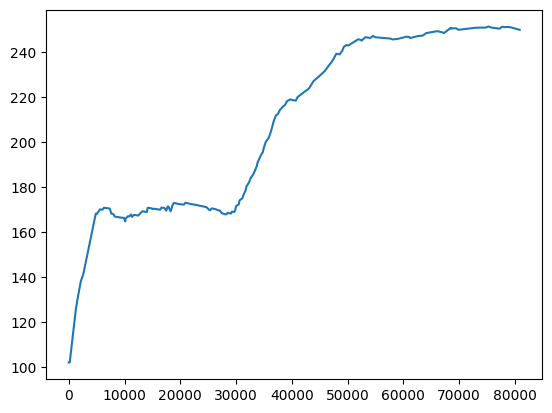

In [24]:
plt.plot(processed_flight["Distance"], processed_flight["CAS"])

In [363]:
segment = get_stable_cas_segment(processed_flight)

In [364]:
segment

,flight_id,timestamp,latitude,longitude,altitude,groundspeed,track,vertical_rate,icao24,u_component_of_wind,...,wind_speed,wind_direction,Distance,Acceleration,Roll_Angle,Climb_Angle,TAS,CAS,wind_dir_cos,wind_dir_sin
22,249486522,2022-02-11 23:29:58+00:00,52.468414,9.649658,575.0,158.0,272.174744,2432.0,249486522,4.335847,...,8.507616,277.835110,8685.433003,0.0,-0.000006,8.009831,166.389837,169.754272,0.995124,0.098631
23,249486522,2022-02-11 23:29:59+00:00,52.468422,9.648586,600.0,158.0,272.174744,2368.0,249486522,4.334180,...,8.509425,278.079898,8923.565743,0.0,0.000000,7.662789,166.394815,169.700154,0.994694,0.102882
24,249486522,2022-02-11 23:30:00+00:00,52.468460,9.647217,650.0,158.0,272.174744,2368.0,249486522,4.332406,...,8.516984,278.587260,9227.817863,0.0,0.000000,9.591303,166.354084,169.540372,0.993744,0.111686
25,249486522,2022-02-11 23:30:01+00:00,52.468460,9.645920,700.0,158.0,272.174744,2304.0,249486522,4.330762,...,8.525420,279.091849,9515.783016,0.0,0.000000,6.835970,166.409418,169.478498,0.992721,0.120433
26,249486522,2022-02-11 23:30:02+00:00,52.468514,9.644237,725.0,158.0,272.175293,NaN,249486522,4.328447,...,8.526385,279.320933,9890.027019,0.0,0.003869,7.500868,166.394813,169.404327,0.992233,0.124392
27,249486522,2022-02-11 23:30:03+00:00,52.468557,9.643099,775.0,158.0,271.812744,NaN,249486522,4.327302,...,8.536763,279.824062,10143.009396,0.5,-6.257502,48.130549,163.767489,166.613111,0.990241,0.139369
28,249486522,2022-02-11 23:30:04+00:00,52.468552,9.643097,800.0,159.0,271.801161,2112.0,249486522,4.327431,...,8.543784,280.082693,10145.160951,0.5,-0.112792,45.658022,165.024723,167.833641,0.989572,0.144037
29,249486522,2022-02-11 23:30:05+00:00,52.468597,9.641037,850.0,159.0,272.161079,2112.0,249486522,4.325098,...,8.552194,280.561862,10602.820365,0.0,2.306683,6.083931,167.419844,170.150418,0.989270,0.146097
30,249486522,2022-02-11 23:30:06+00:00,52.468608,9.639954,875.0,159.0,272.161079,2176.0,249486522,4.323798,...,8.556213,280.795953,10843.387756,0.5,0.000000,8.041507,167.385162,170.055618,0.988665,0.150137
31,249486522,2022-02-11 23:30:07+00:00,52.468655,9.638698,925.0,160.0,272.147585,2240.0,249486522,4.322781,...,8.568479,281.285706,11122.672106,0.0,-0.117139,8.012122,168.386780,170.953535,0.987308,0.158815


In [144]:
df_velocities = pd.read_csv(r"D:\Work\Doing\Aircrafts\B737-800-CFM56-7B24\Controls\velocities_dep.csv")

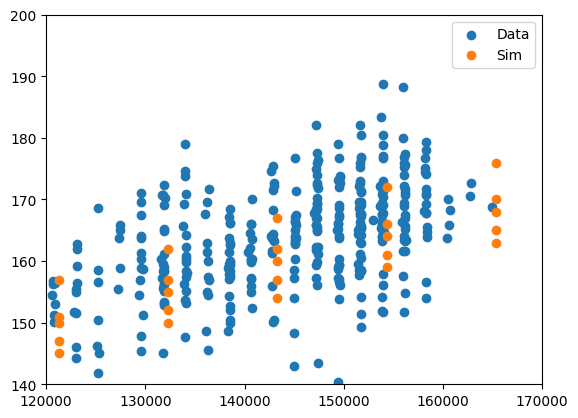

In [330]:
plt.scatter(df_validation["Total_Weight"], df_validation["Vc_1"])
plt.scatter(df_velocities["Weight"], df_velocities["V2"]+15)
plt.ylim([140,200])
plt.xlim([120000, 170000])
plt.legend(["Data", "Sim"])